In [29]:
# ===========================
# Cell 1: Import libraries
# ===========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [30]:
import pandas as pd

# Load student-mat.csv from UCI repository
#url = "/content/student-mat.csv"
data = pd.read_csv("student-mat.csv", sep=';')

# Select relevant columns
data = data[['G1','G2','G3','studytime','failures','absences']]
data.head()


,G1,G2,G3,studytime,failures,absences
0,5,6,6,2,0,6
1,5,5,6,2,0,4
2,7,8,10,2,3,10
3,15,14,15,3,0,2
4,6,10,10,2,0,4


In [3]:
# ===========================
# Cell 3: Split features & target
# ===========================
X = data[['G1','G2','studytime','failures','absences']]
y = data['G3']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===========================
# Cell 4: Scale features
# ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

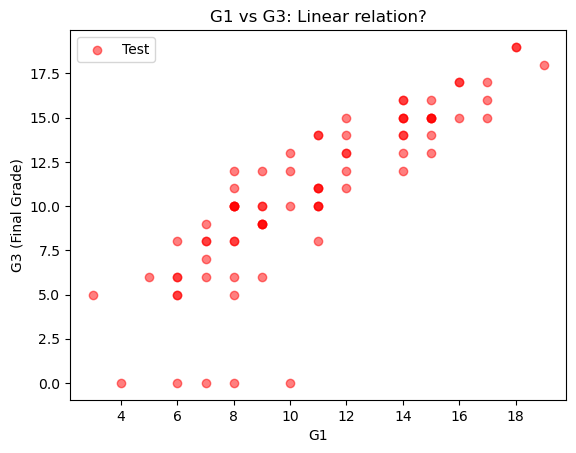

In [32]:
# ===========================
# Cell 5: Visualize relation G1 vs G3
# ===========================
#plt.scatter(X_train['G1'], y_train, color='blue', alpha=0.5, label='Train')
plt.scatter(X_test['G1'], y_test, color='red', alpha=0.5, label='Test')
plt.xlabel("G1")
plt.ylabel("G3 (Final Grade)")
plt.title("G1 vs G3: Linear relation?")
plt.legend()
plt.show()


In [33]:

# ===========================
# Cell 6: Train Linear Regression
# ===========================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


LinearRegression()

In [34]:
# ===========================
# Cell 7: Predictions on test set
# ===========================
y_pred = lr_model.predict(X_test_scaled)



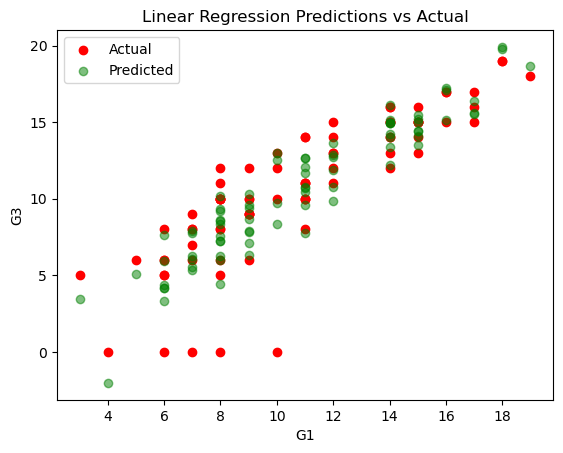

In [45]:
# ===========================
# Cell 8: Plot convergence / fit
# ===========================
plt.scatter(X_test['G1'], y_test, color='red', label='Actual')
plt.scatter(X_test['G1'], y_pred, color='green', alpha=0.5, label='Predicted')
plt.xlabel("G1")
plt.ylabel("G3")
plt.title("Linear Regression Predictions vs Actual")
plt.legend()
plt.show()

In [37]:

# ===========================
# Cell 9: Evaluate model
# ===========================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 4.47
Root Mean Squared Error (RMSE): 2.11
R² Score: 0.78


In [9]:
# ===========================
# Cell 10: Predict new student
# ===========================
new_student = pd.DataFrame([[12, 13, 2, 0, 3]],
                           columns=['G1', 'G2', 'studytime', 'failures', 'absences'])
new_student_scaled = scaler.transform(new_student)
predicted_grade = lr_model.predict(new_student_scaled)
print(f"Predicted final grade (G3) for new student: {predicted_grade[0]:.2f}")

Predicted final grade (G3) for new student: 12.82


<h1> Clustring

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris


In [39]:
iris = load_iris()
X = iris.data
#y = iris.target  # for reference only, not used in clustering
feature_names = iris.feature_names

# Optional: convert to DataFrame for easy visualization
df = pd.DataFrame(X, columns=feature_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [41]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_


C:\Users\iouzarf\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


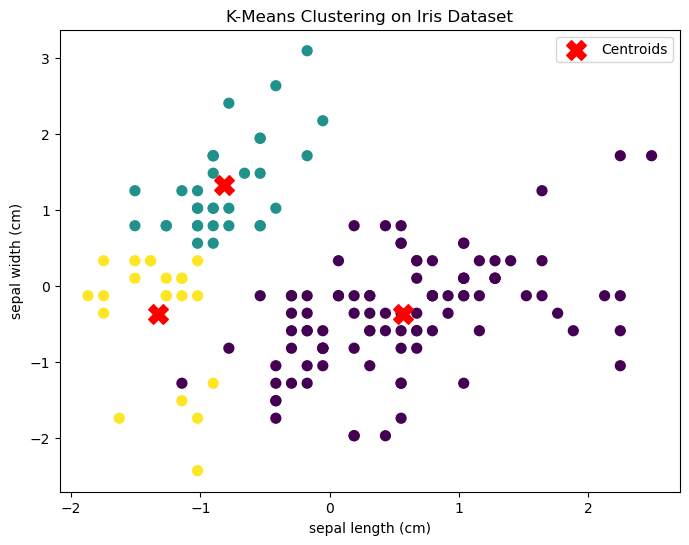

In [42]:
# Using first two features for 2D plot
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis', s=50)
plt.scatter(centroids[:,0], centroids[:,1], color='red', marker='X', s=200, label='Centroids')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('K-Means Clustering on Iris Dataset')
plt.legend()
plt.show()


In [43]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)


Silhouette Score: 0.4798814508199817


In [44]:
# Example new iris sample
new_sample = np.array([[5.0, 3.5, 1.5, 0.3]])  # features
new_sample_scaled = scaler.transform(new_sample)
predicted_cluster = kmeans.predict(new_sample_scaled)
print("New sample assigned to cluster:", predicted_cluster[0])


New sample assigned to cluster: 1
